In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/flavor_globalfit/study_systematic_fit_problem"
os.system(f"mkdir -p {plotting_path}")

0

In [8]:
# load the data
drop_unsuccessful = False
scan_dict = {}
data = {}
for name in ["hese_allfeat_bdtprod_combinedBase","hese_allfeat_bdtprod_combinedBase_withSyst"]:
    print(name)
    scan_dir = scan_dir_dict[name]
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    data[name]["ftau_asimov_poisson"],data[name]["fe_asimov_poisson"],data[name]["ft_grid_asimov_poisson"],data[name]["fe_grid_asimov_poisson"],data[name]["ts_grid_asimov_poisson"] = get_contour_points(scan_dict,name)

hese_allfeat_bdtprod_combinedBase
removed stuff
hese_allfeat_bdtprod_combinedBase_withSyst
removed stuff


Area ratio (hese_allfeat_bdtprod_combinedBase / hese_allfeat_bdtprod_combinedBase) at 68%: 1.0000
Area ratio (hese_allfeat_bdtprod_combinedBase_withSyst / hese_allfeat_bdtprod_combinedBase) at 68%: 0.9034


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:128: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:128: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:128: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:128: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

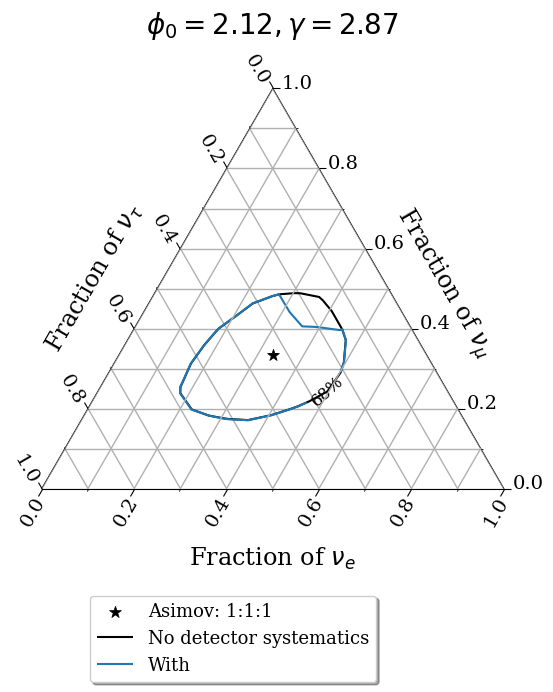

In [10]:
# spice_ftp_oldpid_bdtprod
names = [
"hese_allfeat_bdtprod_combinedBase",
"hese_allfeat_bdtprod_combinedBase_withSyst",
]
labels = [
    "No detector systematics",
    "With",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = None)

for name in names: compare_area( C, alt_key=name, base_key="hese_allfeat_bdtprod_combinedBase", levels=["68%"] )